# M1 — The Forward Adapter `calc_Rrs_from_models_robust`

This notebook is the explainer for **Milestone M1** of the `rob_rt` integration
(`claude_prompts/RT/rob_rt_prompt_2.md`): the working, JIT'd, batched forward
adapter that maps BING model evaluations onto `robust.rt` inputs and back.
M0 (`rob_rt_coding_1.ipynb`) built the configuration surface; M1 built the
physics path itself. Everything below runs against a **real Loisel et al.
(2023) spectrum** — idx=170 on the PACE grid, the same reference spectrum the
test suite's end-to-end fixtures use.

Five sections, matching the five things M1's task 5 promises:

1. **The mapping table, walked through live** — every BING → robust
   conversion step (design §3.4), with real intermediate values.
2. **Baseline-vs-Gordon parity** — the figure behind the Gate's
   `rtol ≤ 1e-5` parity test.
3. **The shape contract** — `(nparam,)` and `(nsamples, nparam)` inputs,
   and what actually comes back (Q4 in the prompt doc's Q&A).
4. **A `DomainWarning`, fired live** — the un-jitted domain check on a
   deliberately turbid IOP set.
5. **What float32 costs — measured, not asserted** (CQ1).

## Setup: one real L23 spectrum

`prep_one_l23` loads L23 spectrum idx=170 interpolated to the PACE grid,
builds the `ExpBricaud`+`Pow` model pair, and produces an `init_guess`
parameter vector from the spectrum's true `a_nw`/`bb_nw` — the same recipe
as the committed Gordon regression fixture
(`bing/tests/files/gen_l23_gordon_fixture.py`). Requires the L23 store
(`$OS_COLOR`); everything downstream of this cell is data-free.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from bing.parameters import standard
from bing.fitting import l23 as fit_l23
from bing.rt import defs as rt_defs
from bing.rt.geometry import ObsGeometry
from bing import evaluate

from robust import rt as robust_rt

# Real L23 reference spectrum: idx=170, PACE grid (same as the test fixtures).
p = standard.expb_pow(satellite='PACE', add_noise=False,
                      variable_Gordon=False, include_Raman=False,
                      include_Chl_fl=False)
prep = fit_l23.prep_one_l23(p, idx=170)
a_model, bb_model = prep['models']

wave = np.asarray(a_model.wave, dtype=np.float64)
Chl = float(np.squeeze(prep['odict']['Chl']))
p0 = np.asarray(prep['p0'], dtype=np.float64)
a_params = p0[:a_model.nparam]     # [Adg, Sdg, Aph] (log10 amplitudes)
bb_params = p0[a_model.nparam:]    # [Bnw, beta]

print(f"wave grid : {wave.size} bands, {wave.min():.0f}-{wave.max():.0f} nm (PACE)")
print(f"L23 truth : Chl = {Chl:.4f} mg/m3 (idx=170)")
print(f"a_params  ({a_model.pnames}) = {np.round(a_params, 4)}")
print(f"bb_params ({bb_model.pnames}) = {np.round(bb_params, 4)}")

wave grid : 61 bands, 400-700 nm (PACE)
L23 truth : Chl = 0.1306 mg/m3 (idx=170)
a_params  (['Adg', 'Sdg', 'Aph']) = [-1.8799  0.017  -1.8799]
bb_params (['Bnw', 'beta']) = [-3.4926  1.    ]


The two remaining ingredients are M0's configuration surface: an `rt_dict`
(from `rt_dict_from_p`, here overridden to select a robust backend) and an
`ObsGeometry`. `Bp_value=0.014` sits inside the hybrid emulator's trained
domain at `theta_s=30°` (section 4 deliberately steps outside it).

In [2]:
rt_dict = rt_defs.rt_dict_from_p(p)          # legacy p -> 'gordon' defaults
rt_dict['rt_backend'] = 'robust_ztt'         # select a robust backend
rt_dict['Bp_value'] = 0.014                  # inside the emulator's trained domain
geom = ObsGeometry(theta_s=30.)              # required -- theta_s never defaults

print("rt_dict :", {k: rt_dict[k] for k in
      ('rt_backend', 'Bp_value', 'fit_Bp', 'include_Raman', 'include_Chl_fl')})
print("geom    :", geom)

rt_dict : {'rt_backend': 'robust_ztt', 'Bp_value': 0.014, 'fit_Bp': False, 'include_Raman': False, 'include_Chl_fl': False}
geom    : ObsGeometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None)


## 1. The mapping table, walked through live

Design §3.4's BING → robust mapping, as `calc_Rrs_from_models_robust`
actually implements it (via the shared `_build_robust_inputs` builder):

| step | BING side | robust side |
|---|---|---|
| 1 | `a_model.eval_a(a_params)`, `bb_model.eval_bb(bb_params)` | total `a`, `bb` on `(nsample, nwave)` |
| 2 | total `a`, `bb` | `IOPs.from_total_bb(a, bb, wave=...)` — robust splits `bb_p = bb − bb_w(λ)` itself |
| 3 | `Bp` kwarg or `rt_dict['Bp_value']` | `PhaseParams(B_p=...)` |
| 4 | `geom` (`ObsGeometry`) | `geom.to_robust()` → `Geometry` (no `Ed` — that seam is M4's) |
| 5 | `include_Raman`/`include_Chl_fl`/`phi_C`/`double_gaussian` | `Inelastic(...)`, or `None` when both are off |
| 6 | `rt_dict['rt_backend']` suffix | `forward(..., mode='ztt'/'hybrid')`, or `baselines.Rrs_gordon` for `robust_baseline` |

**Steps 1–2.** Model evaluation is *identical* to the Gordon path — same
`eval_a`/`eval_bb`, same `(1, nwave)` batch axis for 1-D params. The only new
physics is the water/particle split, which robust owns:

In [3]:
# Steps 1-2: BING model evaluation -> robust IOPs container.
a = a_model.eval_a(a_params)     # total absorption  a_w + a_nw
bb = bb_model.eval_bb(bb_params) # total backscatter bb_w + bb_nw

iops = robust_rt.IOPs.from_total_bb(a, bb, wave=wave)  # a_ph=None: elastic

i440 = int(np.argmin(np.abs(wave - 440.)))
print(f"a  : shape {a.shape},  a(440)  = {a[0, i440]:.5f} m^-1")
print(f"bb : shape {bb.shape},  bb(440) = {bb[0, i440]:.5f} m^-1")
print()
print(f"IOPs leaves are JAX arrays, dtype {np.asarray(iops.a).dtype} "
      "(the float64->float32 crossing, CQ1)")
print(f"iops.bb_w(440) = {float(iops.bb_w[0, i440]):.6f} m^-1 (pure water, robust's table)")
print(f"iops.bb_p(440) = {float(iops.bb_p[0, i440]):.6f} m^-1 (particulate)")
print("bb_p == bb - bb_w exactly? ",
      np.allclose(np.asarray(iops.bb_p), bb - np.asarray(iops.bb_w)))
print(f"iops.u(440)    = {float(iops.u[0, i440]):.5f}   (bb/(a+bb), Gordon's ratio)")

a  : shape (1, 61),  a(440)  = 0.02622 m^-1
bb : shape (1, 61),  bb(440) = 0.00263 m^-1

IOPs leaves are JAX arrays, dtype float32 (the float64->float32 crossing, CQ1)
iops.bb_w(440) = 0.002196 m^-1 (pure water, robust's table)
iops.bb_p(440) = 0.000439 m^-1 (particulate)
bb_p == bb - bb_w exactly?  True
iops.u(440)    = 0.09130   (bb/(a+bb), Gordon's ratio)


Note where the precision crossing actually happens: `IOPs.from_total_bb`
calls `jnp.asarray` on BING's float64 NumPy arrays, and with `jax_enable_x64`
never enabled (CQ1) the leaves land as float32 right here — everything
downstream of step 2 is float32. Section 5 measures what that costs.

**Steps 3–5.** Scalar/config plumbing — no numerics:

In [4]:
# Step 3: the particle phase-function ratio B_p = bb_p/b_p.
phase_params = robust_rt.PhaseParams(B_p=rt_dict['Bp_value'])
print("PhaseParams     :", phase_params)

# Step 4: BING's ObsGeometry -> robust's Geometry (nadir view encoded; Ed=None until M4).
geometry = geom.to_robust()
print("robust Geometry :", geometry)

# Step 5: both inelastic flags are off -> literally None, which robust
# documents as the bit-identical elastic code path (design §3.5).
inelastic = None
print("Inelastic       :", inelastic)

PhaseParams     : PhaseParams(B_p=0.014)
robust Geometry : Geometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None, Ed=None)
Inelastic       : None


**Step 6.** The backend suffix picks the robust entry point. Composing the
pieces by hand and calling `robust.rt.forward` directly must agree with the
one-line adapter call — same inputs, same physics, the only difference being
that the adapter routes through its `lru_cache`d `jax.jit` closure:

In [5]:
# Step 6 by hand: 'robust_ztt' -> mode='ztt'. corrections=False is the
# adapter's own configuration (analytic-only inelastic physics, Q6).
Rrs_manual = np.asarray(robust_rt.forward(
    iops, phase_params, geometry, wave, mode='ztt',
    inelastic=None, corrections=False))

# The same thing through the adapter (jitted, cached):
Rrs_ztt = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_dict, geom=geom)

print(f"manual forward : shape {Rrs_manual.shape}, Rrs(440) = {Rrs_manual[0, i440]:.6e} sr^-1")
print(f"adapter        : shape {Rrs_ztt.shape}, Rrs(440) = {Rrs_ztt[0, i440]:.6e} sr^-1")
print(f"max |manual - adapter| = {np.abs(Rrs_manual - Rrs_ztt).max():.2e} sr^-1 "
      "(jit vs eager float32 rounding only)")

manual forward : shape (1, 61), Rrs(440) = 5.278185e-03 sr^-1
adapter        : shape (1, 61), Rrs(440) = 5.278184e-03 sr^-1
max |manual - adapter| = 9.31e-10 sr^-1 (jit vs eager float32 rounding only)


## 2. Baseline-vs-Gordon parity

`rt_backend='robust_baseline'` dispatches to `robust.rt.baselines.Rrs_gordon`
— robust's re-implementation of the same Gordon (1988) relation BING's
`calc_Rrs_from_models` computes (both use G1=0.0949/G2=0.0794 and the same
A_Rrs/B_Rrs above/below-surface conversion). The Gate's parity test pins this
analytically at `rtol ≤ 1e-5`; this is the same fact, drawn. The two robust
physics backends (`ztt`, `hybrid`) are plotted for context — they *should*
differ from Gordon (that is the point of the integration), and they do,
smoothly and at the few-percent level.

In [6]:
# Gordon path (float64 NumPy end to end) vs robust_baseline (float32 JAX).
rt_gordon = {'variable_Gordon': False, 'include_Raman': False,
             'include_Chl_fl': False}
Rrs_gordon = evaluate.calc_Rrs_from_models(
    a_model, a_params, bb_model, bb_params, rt_gordon)

rt_base = dict(rt_dict, rt_backend='robust_baseline')
Rrs_base = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_base, geom=geom)

# The two real robust backends, for context.
rt_hyb = dict(rt_dict, rt_backend='robust_hybrid')
Rrs_hyb = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_hyb, geom=geom)

Rg, Rb = np.squeeze(Rrs_gordon), np.squeeze(Rrs_base)
rel = np.abs(Rb - Rg) / np.abs(Rg)
print(f"baseline vs Gordon relative difference: max = {rel.max():.2e}, "
      f"median = {np.median(rel):.2e}")
print(f"(gate tolerance is rtol <= 1e-5 -- {1e-5/rel.max():.0f}x of headroom)")

baseline vs Gordon relative difference: max = 2.31e-07, median = 8.17e-08
(gate tolerance is rtol <= 1e-5 -- 43x of headroom)


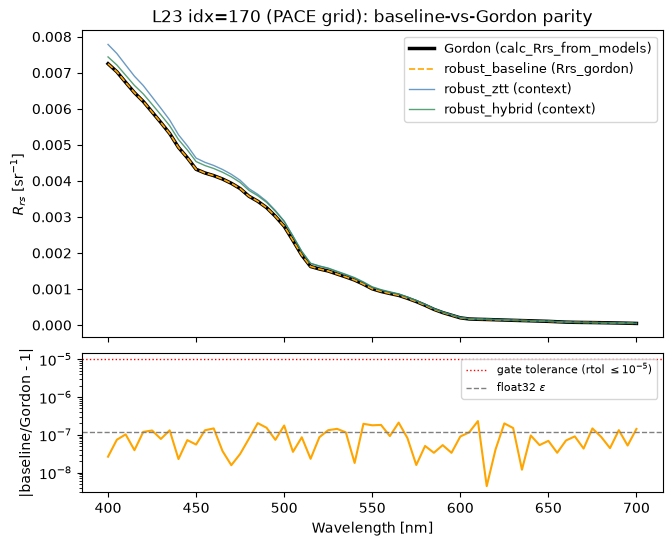

In [7]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.5, 6.), sharex=True,
                               height_ratios=(2.2, 1.),
                               gridspec_kw=dict(hspace=0.07))

ax0.plot(wave, Rg, color='k', lw=2.5, label='Gordon (calc_Rrs_from_models)')
ax0.plot(wave, Rb, color='orange', lw=1.2, ls='--',
         label='robust_baseline (Rrs_gordon)')
ax0.plot(wave, np.squeeze(Rrs_ztt), color='steelblue', lw=1., alpha=0.8,
         label='robust_ztt (context)')
ax0.plot(wave, np.squeeze(Rrs_hyb), color='seagreen', lw=1., alpha=0.8,
         label='robust_hybrid (context)')
ax0.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax0.legend(fontsize=9)
ax0.set_title('L23 idx=170 (PACE grid): baseline-vs-Gordon parity')

ax1.semilogy(wave, rel, color='orange', lw=1.5)
ax1.axhline(1e-5, color='r', ls=':', lw=1.,
            label=r'gate tolerance (rtol $\leq 10^{-5}$)')
ax1.axhline(np.finfo(np.float32).eps, color='gray', ls='--', lw=1.,
            label=r'float32 $\varepsilon$')
ax1.set_ylabel('|baseline/Gordon - 1|')
ax1.set_xlabel('Wavelength [nm]')
ax1.legend(fontsize=8, loc='upper right')
plt.show()

The residual rides at the float32 machine epsilon (gray dashed) — a factor
of ~40 under the gate tolerance (red dotted): the elastic mapping — IOPs
split, Gordon constants, A/B surface conversion — is exactly right, and the
*entire* remaining difference is the float32 downcast (measured properly in
section 5).

## 3. The shape contract

Both adapter twins preserve `eval_a`/`eval_bb`'s leading batch axis: a 1-D
`(nparam,)` input yields `(1, nwave)` — **not** a squeezed `(nwave,)` — and a
`(nsamples, nparam)` batch yields `(nsamples, nwave)` in a single natively
batched call (no `vmap`, no Python loop). This matches
`calc_Rrs_from_models`'s existing behavior exactly (Q4 in the prompt doc:
the Gate's literal "`(nparam,) → (nwave,)`" phrasing was corrected to the
real, shared convention).

In [8]:
# A genuine 1-D parameter vector, and a genuine 5-sample batch around it.
rng = np.random.default_rng(20260830)
nsamples = 5
a_batch = a_params * (1. + 0.02 * rng.standard_normal((nsamples, a_params.size)))
bb_batch = bb_params * (1. + 0.02 * rng.standard_normal((nsamples, bb_params.size)))

Rrs_1d = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_dict, geom=geom)
Rrs_batch = evaluate.calc_Rrs_from_models_robust(
    a_model, a_batch, bb_model, bb_batch, rt_dict, geom=geom)

print(f"1-D input   : a_params {a_params.shape}, bb_params {bb_params.shape}"
      f"  ->  Rrs {Rrs_1d.shape}")
print(f"batch input : a_params {a_batch.shape}, bb_params {bb_batch.shape}"
      f"  ->  Rrs {Rrs_batch.shape}")
print()
# The Gordon twin does the same -- shared convention, not a robust quirk:
Rrs_g1d = evaluate.calc_Rrs_from_models(
    a_model, a_params, bb_model, bb_params, rt_gordon)
print(f"Gordon twin, same 1-D input -> Rrs {Rrs_g1d.shape}  (same convention)")
print()
print(f"batch Rrs(440) spread over the 5 perturbed samples: "
      f"{Rrs_batch[:, i440].min():.4e} to {Rrs_batch[:, i440].max():.4e} sr^-1, "
      f"all finite: {np.all(np.isfinite(Rrs_batch))}")

1-D input   : a_params (3,), bb_params (2,)  ->  Rrs (1, 61)
batch input : a_params (5, 3), bb_params (5, 2)  ->  Rrs (5, 61)

Gordon twin, same 1-D input -> Rrs (1, 61)  (same convention)

batch Rrs(440) spread over the 5 perturbed samples: 5.1874e-03 to 5.5666e-03 sr^-1, all finite: True


## 4. A `DomainWarning`, fired live

The hybrid backend's emulator was trained on a finite IOP domain; outside it,
M3 measured its accuracy as unreliable. The policy (design §4) is
**warn-and-continue** — but under `jax.jit` the inputs are tracers, so the
check is *silent by construction* on the fitting hot path. M1 task 3's
`robust_domain_check` is the sanctioned complement: same argument
construction as the adapter (shared builder — they cannot drift), but one
**un-jitted** `forward` call on concrete arrays, so the warning actually
reaches Python's `warnings` machinery.

Here the turbid set: `Bp_value=0.005`, well below the emulator's trained
lower bound of ~0.01026 (found in task 3 by reading the emulator's actual
trained ranges — the same value the Gate test uses).

In [9]:
rt_turbid = dict(rt_dict, rt_backend='robust_hybrid', Bp_value=0.005)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    evaluate.robust_domain_check(a_model, a_params, bb_model, bb_params,
                                 rt_turbid, geom=geom)

for w in caught:
    print(f"{w.category.__name__}:\n  {w.message}")

  the emulator is being evaluated outside its training range, where M3 measured its accuracy to be unreliable and occasionally worse than the analytic backbone: B_p 100.0% of values outside [0.01026, 0.018], worst 0.005 — 68% of the trained span beyond it. Consider mode='ztt'. (cos_theta_s decreases with solar zenith, so a low sun breaches the lower bound.)


In [10]:
# The jitted hot path on the IDENTICAL inputs: no warning, no error --
# it silently returns finite Rrs (warn-and-continue, design S4 / Q8).
from robust.rt.hybrid import DomainWarning

with warnings.catch_warnings(record=True) as caught_jit:
    warnings.simplefilter('always')
    Rrs_turbid = evaluate.calc_Rrs_from_models_robust(
        a_model, a_params, bb_model, bb_params, rt_turbid, geom=geom)

n_dw = sum(issubclass(w.category, DomainWarning) for w in caught_jit)
print(f"jitted path, same turbid inputs: {n_dw} DomainWarnings, "
      f"Rrs finite: {np.all(np.isfinite(Rrs_turbid))}")
print("-> the fitters (M2) will call robust_domain_check twice per fit --")
print("   initial guess and posterior median -- never inside the hot loop.")

jitted path, same turbid inputs: 0 DomainWarnings, Rrs finite: True
-> the fitters (M2) will call robust_domain_check twice per fit --
   initial guess and posterior median -- never inside the hot loop.


## 5. What float32 costs — measured, not asserted

CQ1: NumPy crosses to JAX exactly once, as float32; `jax_enable_x64` is never
enabled. Section 2 gives a clean instrument for measuring what that costs,
because `robust_baseline` computes the *same physics* as the Gordon path —
the only difference is precision (float64 NumPy end-to-end vs float32 JAX).
So the baseline-vs-Gordon residual **is** the float32 error, isolated:

In [11]:
eps32 = np.finfo(np.float32).eps
absdiff = np.abs(Rb - Rg)

print(f"float32 machine epsilon        : {eps32:.3e}")
print()
print("float32 cost, same physics at both precisions (baseline vs Gordon):")
print(f"  relative : max {rel.max():.2e}  ({rel.max()/eps32:.1f} x eps32), "
      f"median {np.median(rel):.2e}")
print(f"  absolute : max {absdiff.max():.2e} sr^-1, "
      f"median {np.median(absdiff):.2e} sr^-1")
print()
median_Rrs = np.median(Rg)
noise_2pct = 0.02 * median_Rrs
print(f"scale: median Rrs(L23 idx=170)  = {median_Rrs:.3e} sr^-1")
print(f"       2% measurement noise     = {noise_2pct:.3e} sr^-1")
print(f"       -> float32 error is {noise_2pct/absdiff.max():,.0f}x smaller "
      "than a 2%-noise floor")

float32 machine epsilon        : 1.192e-07

float32 cost, same physics at both precisions (baseline vs Gordon):
  relative : max 2.31e-07  (1.9 x eps32), median 8.17e-08
  absolute : max 7.71e-10 sr^-1, median 8.13e-11 sr^-1

scale: median Rrs(L23 idx=170)  = 1.007e-03 sr^-1
       2% measurement noise     = 2.014e-05 sr^-1
       -> float32 error is 26,124x smaller than a 2%-noise floor


A second, independent look at the same noise floor: task 1's tests found that
switching `Inelastic` on moves `rrs_forward` onto a different static code
path, so even where the fluorescence kernel is ~0 the elastic backbone
recomputes with fresh float32 rounding. Reproduced live — the "negative
fluorescence" dips are pure ULP noise, five orders of magnitude below the
real 685 nm emission signal:

In [12]:
from correct_atmosphere import downwelling

# Fluorescence needs the downwelling irradiance and the Chl-fluorescence init.
Ed = downwelling.downwelling_irradiance(wave, 0.)
a_model.init_Chl_fluorescence(Ed=Ed)

rt_fl = dict(rt_dict, include_Chl_fl=True, phi_C=0.02, double_gaussian=True)
Rrs_fl = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_fl, geom=geom)
Rrs_el = evaluate.calc_Rrs_from_models_robust(
    a_model, a_params, bb_model, bb_params, rt_dict, geom=geom)

dfl = np.squeeze(Rrs_fl) - np.squeeze(Rrs_el)
i685 = int(np.argmin(np.abs(wave - 685.)))
neg = dfl < 0
print(f"(Rrs_fluor - Rrs_elastic) at the 685 nm peak : {dfl[i685]:+.2e} sr^-1")
print(f"negative dips (pure float32 path noise)      : {neg.sum()}/{dfl.size} "
      f"wavelengths, worst {dfl[neg].min():+.2e} sr^-1")
print(f"signal / noise-floor ratio                   : "
      f"{dfl[i685]/np.abs(dfl[neg].min()):,.0f}x")

(Rrs_fluor - Rrs_elastic) at the 685 nm peak : +7.08e-05 sr^-1
negative dips (pure float32 path noise)      : 15/61 wavelengths, worst -4.66e-10 sr^-1
signal / noise-floor ratio                   : 151,980x


**Measured bottom line.** On this real L23 spectrum, the float32 downcast
costs at most ~2.3e-7 in relative terms (≈1.9 float32 ULPs) — under 8e-10
sr⁻¹ absolute, roughly 26,000× below even an optimistic 2% measurement-noise
floor, and the independent inelastic-path check puts the same noise floor at
~5e-10 sr⁻¹ against a 7e-5 sr⁻¹ fluorescence signal. Float32 is, as CQ1's
docstring asserts, more than sufficient precision for this problem — and now
that is a measurement, not an assertion.

## What's next

M1 is complete: the adapter, its JIT cache, the un-jitted domain check, the
`RT_correction` deletion (pinned by the committed L23 Gordon fixture), and
this notebook. **M2** (`claude_prompts/RT/rob_rt_prompt_3.md`) wires
`rt_dict['rt_backend']` into the fitters: dispatch, `validate_rt_dict` at fit
setup, `robust_domain_check` around sampling, and geometry threading.